# Rice Classifier

In [65]:
import pandas as pd
from sklearn.datasets import load_iris
from ucimlrepo import fetch_ucirepo 
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay

In [66]:
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score

In [72]:
# Load dataset
rice = fetch_ucirepo(id=545)
X = rice.data.features
y = rice.data.targets

# Display some data
print(X.head(10))
print(y.head(10))

print(X.tail(10))
print(y.tail(10))

    Area   Perimeter  Major_Axis_Length  Minor_Axis_Length  Eccentricity  \
0  15231  525.578979         229.749878          85.093788      0.928882   
1  14656  494.311005         206.020065          91.730972      0.895405   
2  14634  501.122009         214.106781          87.768288      0.912118   
3  13176  458.342987         193.337387          87.448395      0.891861   
4  14688  507.166992         211.743378          89.312454      0.906691   
5  13479  477.015991         200.053055          86.650291      0.901328   
6  15757  509.281006         207.296677          98.336136      0.880323   
7  16405  526.570007         221.612518          95.436707      0.902521   
8  14534  483.640991         196.650818          95.050682      0.875429   
9  13485  471.570007         198.272644          87.727287      0.896789   

   Convex_Area    Extent  
0        15617  0.572896  
1        15072  0.615436  
2        14954  0.693259  
3        13368  0.640669  
4        15262  0.646024  
5

### The 10th–90th percentile range of each feature is calculated for each class separately. Comparing these ranges helps identify which features have non-overlapping distributions between the two classes, which would suggest a clear decision boundary exists and that an SVM is a suitable approach.

In [68]:
# Print the 10th–90th percentile range of each feature for each class to assess separability
y_series = y.iloc[:, 0]

for cls in ['Cammeo', 'Osmancik']:
    for feature in X.columns:
        X_class = X[y_series == cls]
        lower = X_class[feature].quantile(0.10)
        upper = X_class[feature].quantile(0.90)
        print(f"{feature} | Class {cls}: {lower:.2f} – {upper:.2f}")
    print()

Area | Class Cammeo: 12466.80 – 15773.40
Perimeter | Class Cammeo: 457.69 – 515.27
Major_Axis_Length | Class Cammeo: 192.45 – 218.63
Minor_Axis_Length | Class Cammeo: 82.04 – 95.36
Eccentricity | Class Cammeo: 0.88 – 0.92
Convex_Area | Class Cammeo: 12778.90 – 16111.10
Extent | Class Cammeo: 0.56 – 0.78

Area | Class Osmancik: 10245.50 – 12800.20
Perimeter | Class Osmancik: 404.32 – 454.91
Major_Axis_Length | Class Osmancik: 164.78 – 188.81
Minor_Axis_Length | Class Osmancik: 77.70 – 91.13
Eccentricity | Class Osmancik: 0.85 – 0.90
Convex_Area | Class Osmancik: 10478.90 – 13098.40
Extent | Class Osmancik: 0.59 – 0.78



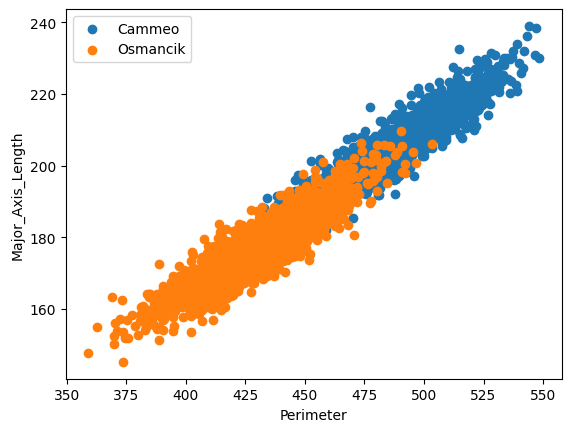

In [69]:
# Scatter plot of Perimeter and Major_Axis_Length coloured by class to assess the decision boundary
plt.scatter(X[y_series == 'Cammeo']['Perimeter'], X[y_series == 'Cammeo']['Major_Axis_Length'], label='Cammeo')
plt.scatter(X[y_series == 'Osmancik']['Perimeter'], X[y_series == 'Osmancik']['Major_Axis_Length'], label='Osmancik')
plt.xlabel('Perimeter')
plt.ylabel('Major_Axis_Length')
plt.legend()
plt.show()

## Fit the SVM

In [74]:
# Prepare features and labels
X_svm = X[['Perimeter', 'Major_Axis_Length']]
y_svm = y_series

# Split data
X_train, X_test, y_train, y_test = train_test_split(X_svm, y_svm, test_size=0.2, random_state=42)

# Scale features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Fit SVM
svm = SVC(kernel='linear')
svm.fit(X_train, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


## Evaluation

In [75]:
# Accuracy
print("Accuracy")
print(f"{accuracy_score(y_test, y_pred):.4f}")

Accuracy
0.9344


In [76]:
# Classification report
print("Classification Report")
print(classification_report(y_test, y_pred))

Classification Report
              precision    recall  f1-score   support

      Cammeo       0.93      0.93      0.93       350
    Osmancik       0.94      0.94      0.94       412

    accuracy                           0.93       762
   macro avg       0.93      0.93      0.93       762
weighted avg       0.93      0.93      0.93       762



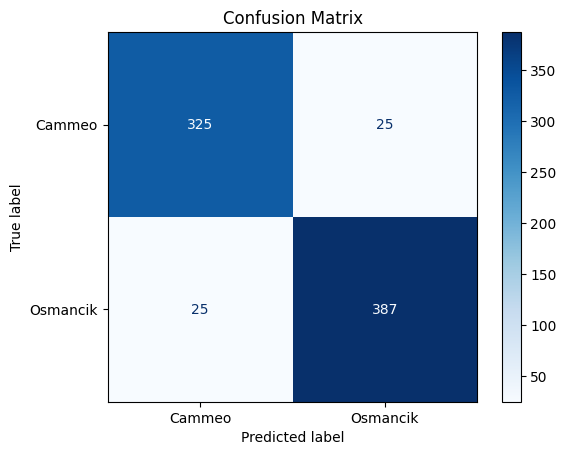

In [77]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=svm.classes_)
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()